In [1]:
import pandas as pd
df = pd.read_csv("Chile.csv")

print(df.head())
print('df.shape:', df.shape)

   Unnamed: 0 region  population sex   age education   income  statusquo vote
0           1      N      175000   M  65.0         P  35000.0    1.00820    Y
1           2      N      175000   M  29.0        PS   7500.0   -1.29617    N
2           3      N      175000   F  38.0         P  15000.0    1.23072    Y
3           4      N      175000   F  49.0         P  35000.0   -1.03163    N
4           5      N      175000   F  23.0         S  35000.0   -1.10496    N
df.shape: (2700, 9)


In [2]:
print('\n describe: ', df.describe())


 describe:          Unnamed: 0     population          age         income     statusquo
count  2700.000000    2700.000000  2699.000000    2602.000000  2.683000e+03
mean   1350.500000  152222.222222    38.548722   33875.864719 -1.118151e-08
std     779.567188  102198.039602    14.756415   39502.867120  1.000186e+00
min       1.000000    3750.000000    18.000000    2500.000000 -1.803010e+00
25%     675.750000   25000.000000    26.000000    7500.000000 -1.002235e+00
50%    1350.500000  175000.000000    36.000000   15000.000000 -4.558000e-02
75%    2025.250000  250000.000000    49.000000   35000.000000  9.685750e-01
max    2700.000000  250000.000000    70.000000  200000.000000  2.048590e+00


In [3]:
print("\nmean of income", df['income'].mean())
print("var of income", df['income'].var())
print("std of income", df['income'].sem())


mean of income 33875.86471944658
var of income 1560476510.6898816
std of income 774.4171671433221


In [5]:
import numpy as np
# calculate mean of income (average height of students)
print("mean:", df['income'].mean())
print("min:", df['income'].min())
print("max:", df['income'].max())
# variance (ddof = 1 - to calculate the "sample variance") 
print("var:", df['income'].var(ddof=1))
print("std:", np.std(df['income']))

mean: 33875.86471944658
min: 2500.0
max: 200000.0
var: 1560476510.6898816
std: 39495.27552430943


In [6]:
print("\neducation ", df['education'].count())
print("education counts:", df['education'].value_counts())
print("vote:", df['vote'].value_counts())


education  2689
education counts: education
S     1120
P     1107
PS     462
Name: count, dtype: int64
vote: vote
N    889
Y    868
U    588
A    187
Name: count, dtype: int64


In [7]:
df['income'].dropna()

0       35000.0
1        7500.0
2       15000.0
3       35000.0
4       35000.0
         ...   
2695    15000.0
2696    15000.0
2697    75000.0
2698    75000.0
2699    35000.0
Name: income, Length: 2602, dtype: float64

In [8]:
df.groupby('region')['income'].mean() #average income by region

region
C     31321.243523
M     26505.376344
N     30764.331210
S     27087.517934
SA    42442.872688
Name: income, dtype: float64

In [9]:
print("\neducation mean:" , df.groupby('education')['income'].mean()) #average income by education

print("\n\ngroupby:", df.groupby(['education', 'vote'])['income'].mean())


education mean: education
P     17716.884328
PS    68325.842697
S     35868.959108
Name: income, dtype: float64


groupby: education  vote
P          A       19489.795918
           N       16650.763359
           U       16783.216783
           Y       18469.512195
PS         A       48467.741935
           N       63238.636364
           U       58281.250000
           Y       88252.032520
S          A       35176.767677
           N       36071.428571
           U       30325.112108
           Y       39975.328947
Name: income, dtype: float64


### Histogram

A histogram is a graphical representation of the distribution of numerical data, where the data is grouped into continuous, non-overlapping intervals called bins, and the height of each bar reflects the frequency (or density) of values falling within each bin. 

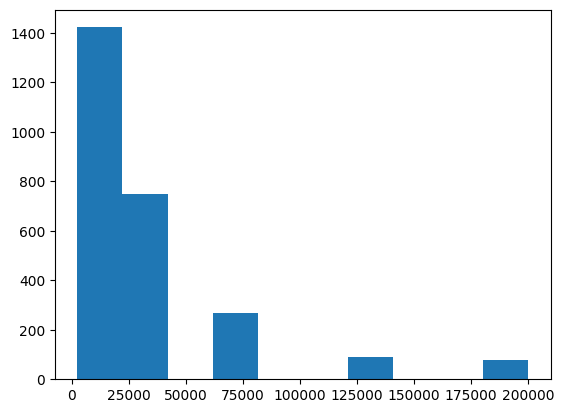

In [10]:
import matplotlib.pyplot as plt

#plot income
plt.hist(df['income'].dropna()) #income
plt.show()

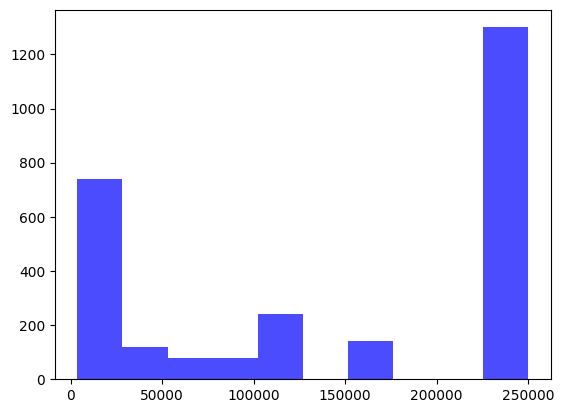

In [11]:
#plot population
num_bins = 10
plt.hist(df['population'], num_bins, facecolor='blue', alpha=0.7) #density=1, 
plt.show()

### Boxplot

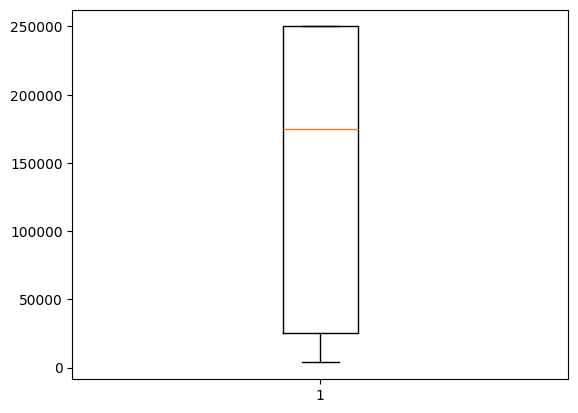

In [12]:
#boxplot
y = list(df.population)
plt.boxplot(y)
plt.show()

A **boxplot** provides a quick visual summary of the distribution of a dataset, highlighting:

1. **Median and Quartiles** – Displays the central tendency and spread via the median, the first quartile (Q1), and the third quartile (Q3).  
2. **Range of Data** – Whiskers typically show the data range or a specific cutoff for outliers.  
3. **Outlier Detection** – Points lying beyond the whiskers indicate potential outliers.  
4. **Comparison Across Groups** – Multiple boxplots can be placed side by side to compare distributions.

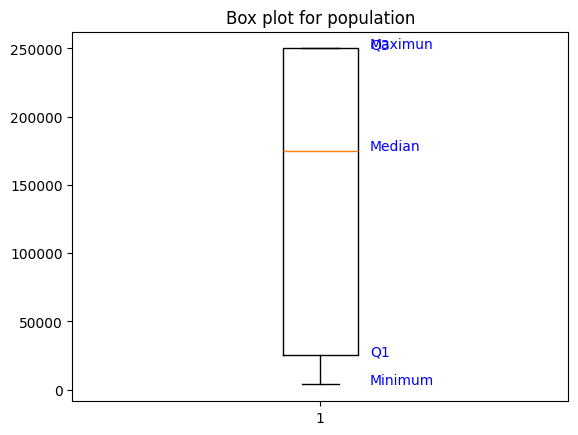

In [13]:
# Adding some explanation:
plt.boxplot(y)
plt.text(1.1, np.percentile(y,  [0]), 'Minimum', color='blue')
plt.text(1.1, np.percentile(y, [25]), 'Q1', color='blue')
plt.text(1.1, np.percentile(y, [50]), 'Median', color='blue')
plt.text(1.1, np.percentile(y, [75]), 'Q3', color='blue')
plt.text(1.1, np.percentile(y,[100]), 'Maximun', color='blue')
plt.title("Box plot for population")
plt.show()

Manually Calculate the values required for drawing a boxplot

In [14]:
import numpy as np

# Calculate quartiles
Q1 = np.percentile(y, 25)
Q3 = np.percentile(y, 75)

# Interquartile Range
IQR = Q3 - Q1

# Calculate fences
lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

print("Q1 (25th percentile):", Q1)
print("Q3 (75th percentile):", Q3)
print("IQR:", IQR)
print("Lower fence:", lower_fence)
print("Upper fence:", upper_fence)

Q1 (25th percentile): 25000.0
Q3 (75th percentile): 250000.0
IQR: 225000.0
Lower fence: -312500.0
Upper fence: 587500.0


See documentation for definition of box and whiskers: 

https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.boxplot.html#matplotlib.axes.Axes.boxplot


<Axes: >

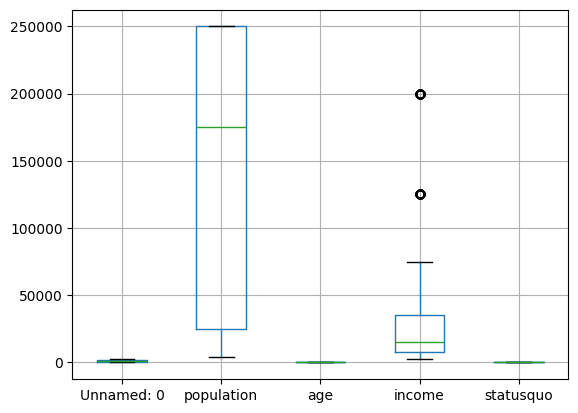

In [15]:
# The DataFrame has a direct method for making a boxplot:
df.boxplot()

array([[<Axes: title={'center': 'Unnamed: 0'}, xlabel='[sex]'>,
        <Axes: title={'center': 'age'}, xlabel='[sex]'>],
       [<Axes: title={'center': 'income'}, xlabel='[sex]'>,
        <Axes: title={'center': 'population'}, xlabel='[sex]'>],
       [<Axes: title={'center': 'statusquo'}, xlabel='[sex]'>, <Axes: >]],
      dtype=object)

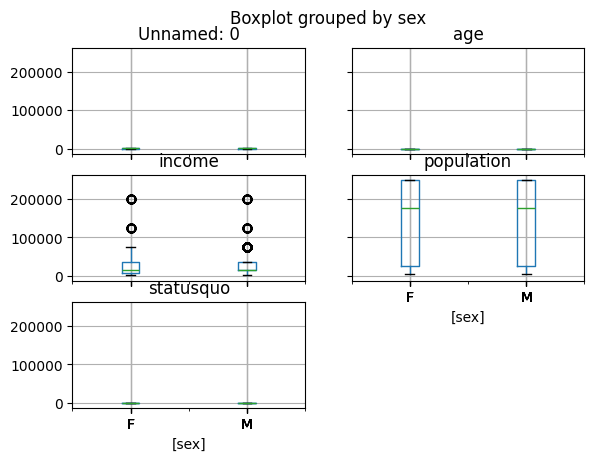

In [16]:
df.boxplot(by='sex')

## Pie Chart

For the CSV file data on students' Gender, make a pie chart.

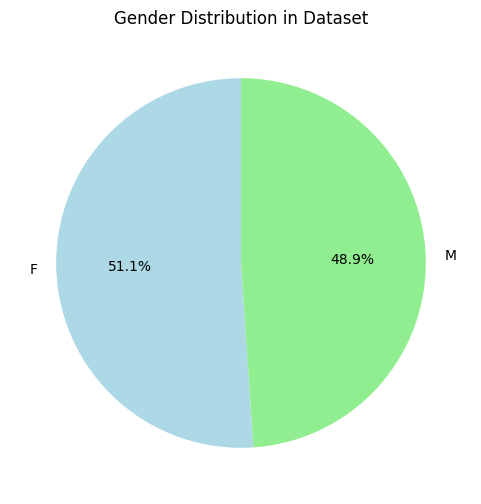

In [17]:
# Count the occurrences of each gender
gender_counts = df['sex'].value_counts()

# Plot a pie chart of gender distribution
plt.figure(figsize=(6, 6))
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=90, colors=['lightblue', 'lightgreen'])
plt.title('Gender Distribution in Dataset')
plt.show()

## Covariance and Correlation Coefficient
### 1. Sample Covariance

Let $\{(x_1, y_1), (x_2, y_2), \dots, (x_n, y_n)\}$ be the data pairs, and let
$
\bar{x} = \frac{1}{n}\sum_{i=1}^n x_i, 
\quad 
\bar{y} = \frac{1}{n}\sum_{i=1}^n y_i
$
be the sample means of $x$ and $y$, respectively. Then the **sample covariance** is given by

$
\mathrm{Cov}(x, y)
= \frac{1}{n-1}\sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y}).
$

---

### 2. Sample Pearson Correlation Coefficient

The **sample Pearson correlation coefficient** (often just called the correlation coefficient) is defined as:

$
r_{xy}
= \frac{\mathrm{Cov}(x, y)}{s_x \, s_y}
$

where $s_x$ and $s_y$ are the sample standard deviations of $x$ and $y$, respectively:

$
s_X 
= \sqrt{\frac{1}{n-1} \sum_{i=1}^n (x_i - \bar{x})^2}, 
\quad
s_Y 
= \sqrt{\frac{1}{n-1} \sum_{i=1}^n (y_i - \bar{y})^2}.
$

Hence, putting it all together:

$
r_{xy}
= \frac{ \frac{1}{n-1}\sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y}) }
       { \sqrt{\frac{1}{n-1} \sum_{i=1}^n (x_i - \bar{x})^2} \,\sqrt{\frac{1}{n-1} \sum_{i=1}^n (y_i - \bar{y})^2} }.
$

This correlation coefficient $r_{xy}$ always lies between $-1$ and $+1$.

In [18]:
clean_df = df[['age', 'income']].dropna()
clean_df.shape

(2601, 2)

In [19]:
import numpy as np

# Covariance calculation
cov_matrix = np.cov(clean_df['age'], clean_df['income'])
covariance = cov_matrix[0, 1]

# Correlation coefficient calculation
correlation = np.corrcoef(clean_df['age'], clean_df['income'])[0, 1]

print(f"Covariance: {covariance:.2f}")
print(f"Correlation coefficient: {correlation:.2f}") #week correlation

Covariance: -18799.06
Correlation coefficient: -0.03


## Scatter Plot
1. **Correlation Coefficient Calculation**  
   The code calculates the Pearson correlation coefficient between the `income` and `age`. This value indicates the strength and direction of the linear relationship between income and age. A positive value means that as age increases, income tends to increase.
2. **Scatter Plot**  
   The code generates a scatter plot of the given income and age data, with age on the x-axis and income on the y-axis. Each point on the plot corresponds to one pair of (income, age) values. This visual representation helps confirm the correlation observed numerically; if most points roughly follow a straight line sloping upward, it suggests a positive linear relationship.

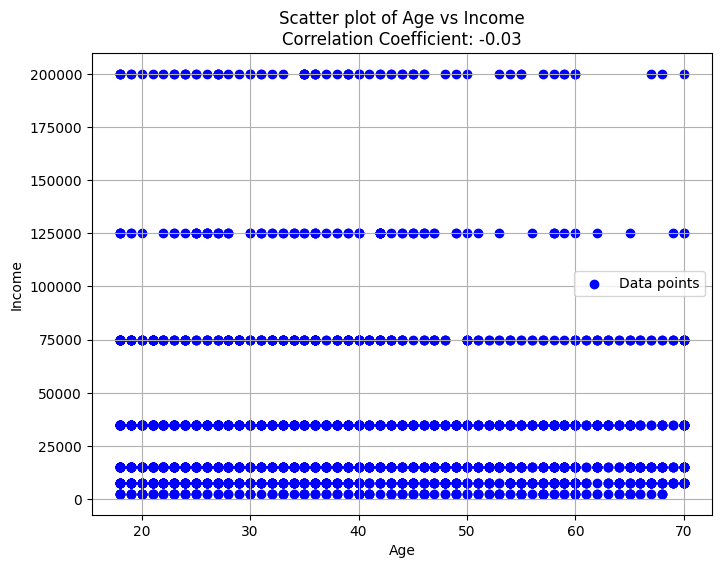

In [50]:
import numpy as np
import matplotlib.pyplot as plt

# Calculate correlation coefficient
correlation = np.corrcoef(clean_df['age'], clean_df['income'])[0, 1]

# Create scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(clean_df['age'], clean_df['income'], color='b', label='Data points')

# Add labels and title
plt.xlabel('Age')
plt.ylabel('Income')
plt.title(f'Scatter plot of Age vs Income\nCorrelation Coefficient: {correlation:.2f}')

# Display the plot
plt.legend()
plt.grid(True)
plt.show()